# Predict the Car Price for Chaky Company

Chaky company has trouble setting a price for the cars it sells, so this notebook builds a model that predicts a car's selling price from its specifications.

- **Problem type:** regression - the target `selling_price` is continuous.
- **Data:** `datasets/Cars.csv`, 8,128 used-car listings with 13 columns.
- **Target:** `selling_price`, log transformed during modelling because the raw price is heavily right skewed, then converted back with `np.exp` before any metric is reported.
- **Flow:** load the data, explore it, clean it, split it, compare models with cross-validation, tune the winner, test it once, look at what drives the predictions, and save the pipeline.

## 1. Import libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Configure path for saving figures 
FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"pandas {pd.__version__}, numpy {np.__version__}")

pandas 3.0.5, numpy 2.5.2


## 2. Load the data

In [2]:
# Define data path and load the dataset
data_path = "../datasets/Cars.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 3. Exploratory Data Analysis

The analysis below is done on the raw dataset, before any cleaning, so that it can drive the
preprocessing decisions in section 4 rather than justify them after the fact.

### 3.1 Data overview

In [3]:
print("Dataset information:")
df.info()

print("Numeric summary:")
display(df.describe())

print("Full summary, including the object columns:")
display(df.describe(include="all").T)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB
Numeric summary:


,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


Full summary, including the object columns:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`mileage`, `engine` and `max_power` are stored as text with their units attached ("23.4 kmpl", "1248 CC"), and `name` holds the full model string. A working copy `eda_df` is made with those columns parsed to numbers and `brand` pulled out of `name`, purely so the plots below can be drawn.

In [4]:
eda_df = df.copy()
for column in ["mileage", "engine", "max_power"]:
    eda_df[column] = pd.to_numeric(
        eda_df[column].astype("string").str.extract(r"([-+]?\d*\.?\d+)", expand=False),
        errors="coerce"
    )
eda_df["brand"] = eda_df["name"].astype("string").str.split().str[0]

numeric_features = ["year", "km_driven", "mileage", "engine", "max_power", "seats"]
categorical_features = ["fuel", "seller_type", "transmission", "owner"]

### 3.2 Missing values and duplicates

In [5]:
# Missing values decide which imputers the pipeline needs later on
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percentage=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values("missing_count", ascending=False)
)
display(missing_summary)

# Count duplicate rows to see if we need to drop them
print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_percentage
torque,222,2.731299
mileage,221,2.718996
engine,221,2.718996
seats,221,2.718996
max_power,215,2.645177
name,0,0.000000
year,0,0.000000
selling_price,0,0.000000
km_driven,0,0.000000
fuel,0,0.000000


Duplicate rows: 1202


### 3.3 Categorical variables

In [6]:
# Check the categories, their spelling, and how imbalanced they are
for column in df.select_dtypes(include=["object", "string"]).columns:
    print(f"\n{column} unique values:")
    display(df[column].value_counts(dropna=False).head(15))


name unique values:


name
Maruti Swift Dzire VDI                    129
Maruti Alto 800 LXI                        82
Maruti Alto LXi                            71
BMW X4 M Sport X xDrive20d                 62
Maruti Swift VDI                           61
Maruti Swift VDI BSIV                      59
Maruti Wagon R LXI                         53
Maruti Alto K10 VXI                        50
Hyundai EON Era Plus                       48
Maruti Wagon R VXI BS IV                   45
Maruti Ertiga VDI                          45
Maruti Alto LX                             44
Toyota Innova 2.5 VX (Diesel) 7 Seater     44
Maruti Ritz VDi                            42
Maruti Swift Dzire VXI                     38
Name: count, dtype: int64


fuel unique values:


fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64


seller_type unique values:


...

engine
1248 CC    1017
1197 CC     832
998 CC      453
796 CC      444
2179 CC     389
1498 CC     375
1396 CC     321
1199 CC     271
2494 CC     222
NaN         221
2523 CC     195
1461 CC     185
1198 CC     182
1497 CC     181
1582 CC     156
Name: count, dtype: int64


max_power unique values:


max_power
74 bhp       377
81.80 bhp    220
NaN          215
88.5 bhp     204
67 bhp       165
46.3 bhp     162
67.1 bhp     151
88.7 bhp     148
67.04 bhp    145
47.3 bhp     141
62.1 bhp     141
70 bhp       141
88.73 bhp    132
81.86 bhp    131
120 bhp      131
Name: count, dtype: int64


torque unique values:


torque
190Nm@ 2000rpm           530
200Nm@ 1750rpm           445
90Nm@ 3500rpm            405
113Nm@ 4200rpm           223
NaN                      222
114Nm@ 4000rpm           171
62Nm@ 3000rpm            164
69Nm@ 3500rpm            141
160Nm@ 2000rpm           138
330Nm@ 1600-2800rpm      122
74.5Nm@ 4000rpm          121
59Nm@ 2500rpm            112
110Nm@ 4800rpm           112
219.7Nm@ 1500-2750rpm    101
195Nm@ 1400-2200rpm      101
Name: count, dtype: int64

### 3.4 Univariate analysis

One variable at a time, starting with the target.

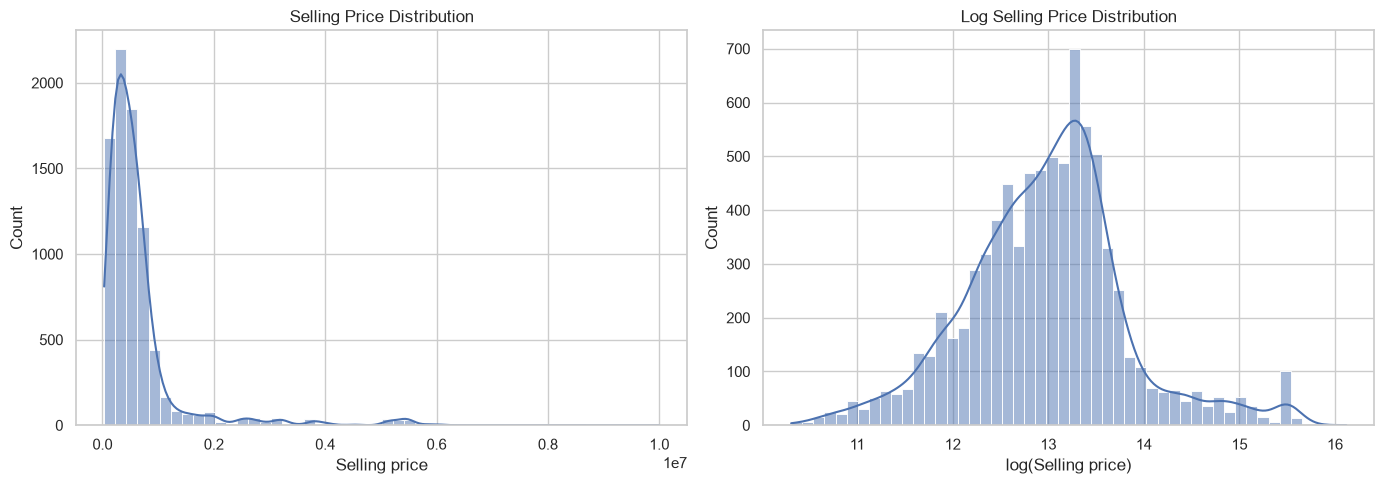

In [7]:
# Raw price next to log price, to see what the log transform actually fixes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(eda_df["selling_price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Selling Price Distribution")
axes[0].set_xlabel("Selling price")
sns.histplot(np.log(eda_df["selling_price"]), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log Selling Price Distribution")
axes[1].set_xlabel("log(Selling price)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_target_distribution.png", dpi=160)
plt.show()

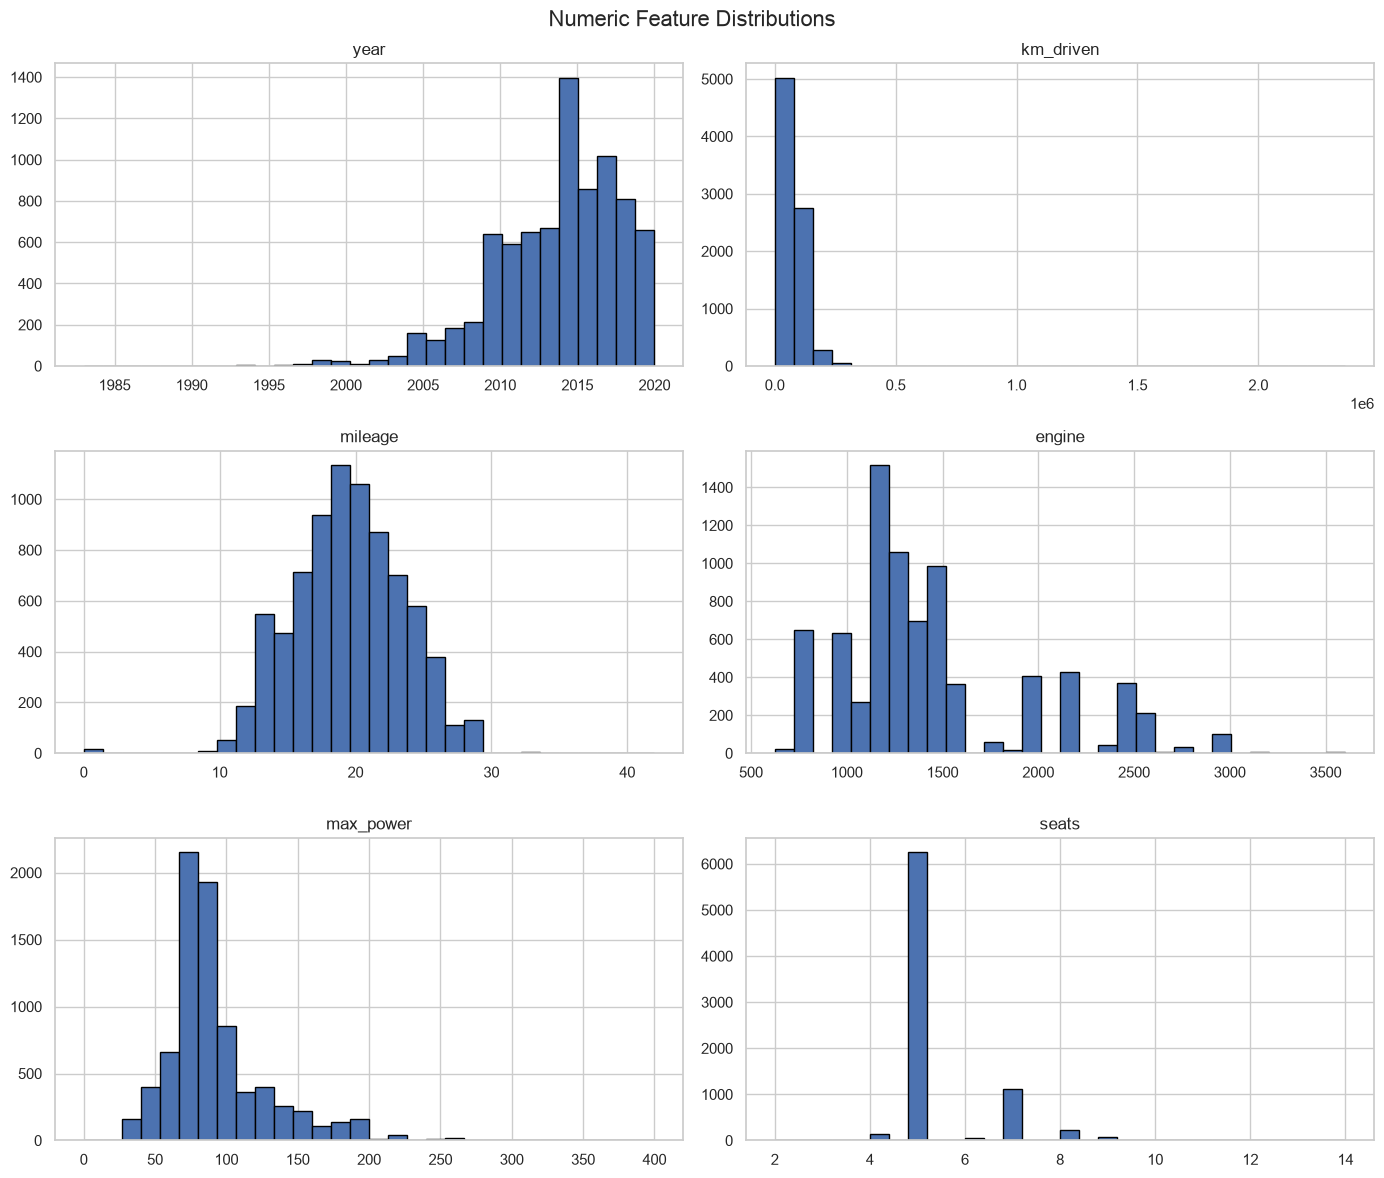

In [8]:
# Distribution of every numeric feature
eda_df[numeric_features].hist(bins=30, figsize=(14, 12), edgecolor="black")
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_numeric_feature_distributions.png", dpi=160)
plt.show()

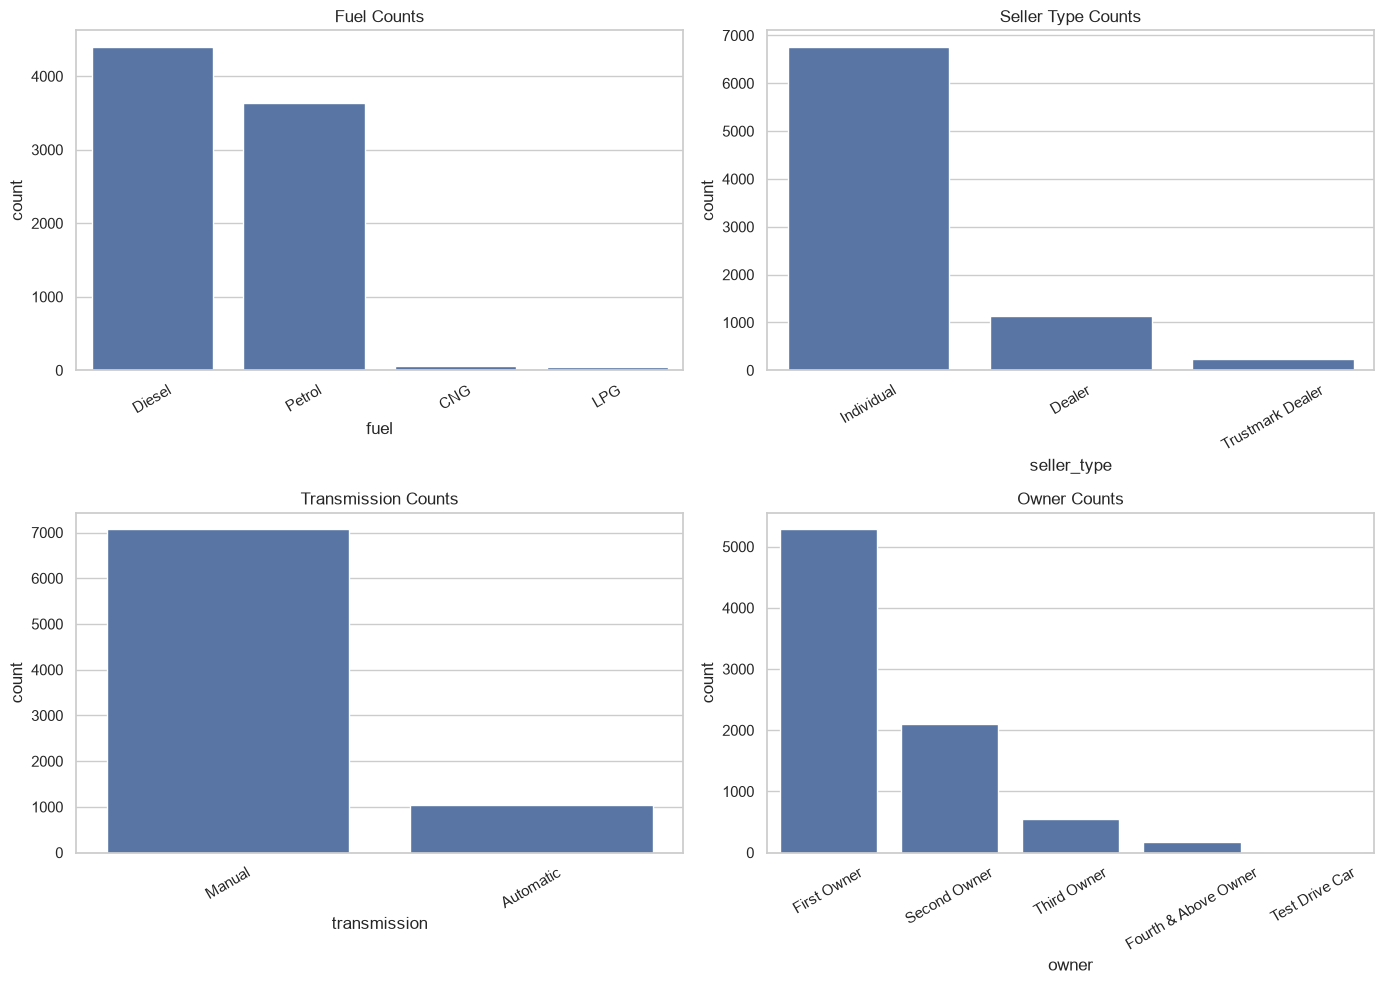

In [9]:
# How often each category appears
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, column in zip(axes.flat, categorical_features):
    order = df[column].value_counts(dropna=False).index
    sns.countplot(data=df, x=column, order=order, ax=ax)
    ax.set_title(f"{column.replace('_', ' ').title()} Counts")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_categorical_feature_counts.png", dpi=160)
plt.show()

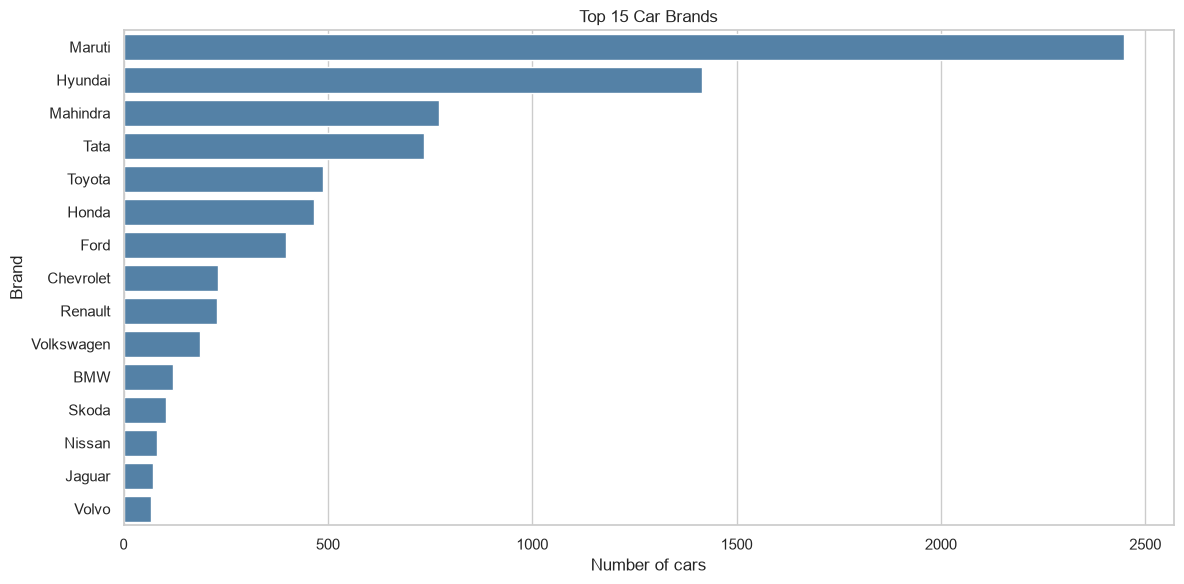

,count,mean,median
brand,,,
BMW,120,4.109917e+06,5400000.0
Volvo,67,3.272015e+06,3400000.0
Jaguar,71,2.915465e+06,3000000.0
Toyota,488,9.599467e+05,750000.0
Skoda,105,6.077238e+05,645000.0
Honda,467,5.961780e+05,570000.0
Mahindra,772,6.232241e+05,560000.0
Ford,397,5.166826e+05,480000.0
Hyundai,1415,4.585544e+05,434999.0


In [10]:
# Count brands and plot the top 15 brands
top_brands = eda_df["brand"].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, color="steelblue")
plt.title("Top 15 Car Brands")
plt.xlabel("Number of cars")
plt.ylabel("Brand")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_top_brands.png", dpi=160)
plt.show()

brand_price = (
    eda_df[eda_df["brand"].isin(top_brands.index)]
    .groupby("brand")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)
display(brand_price)

### 3.5 Multivariate analysis

How each feature moves with the price.

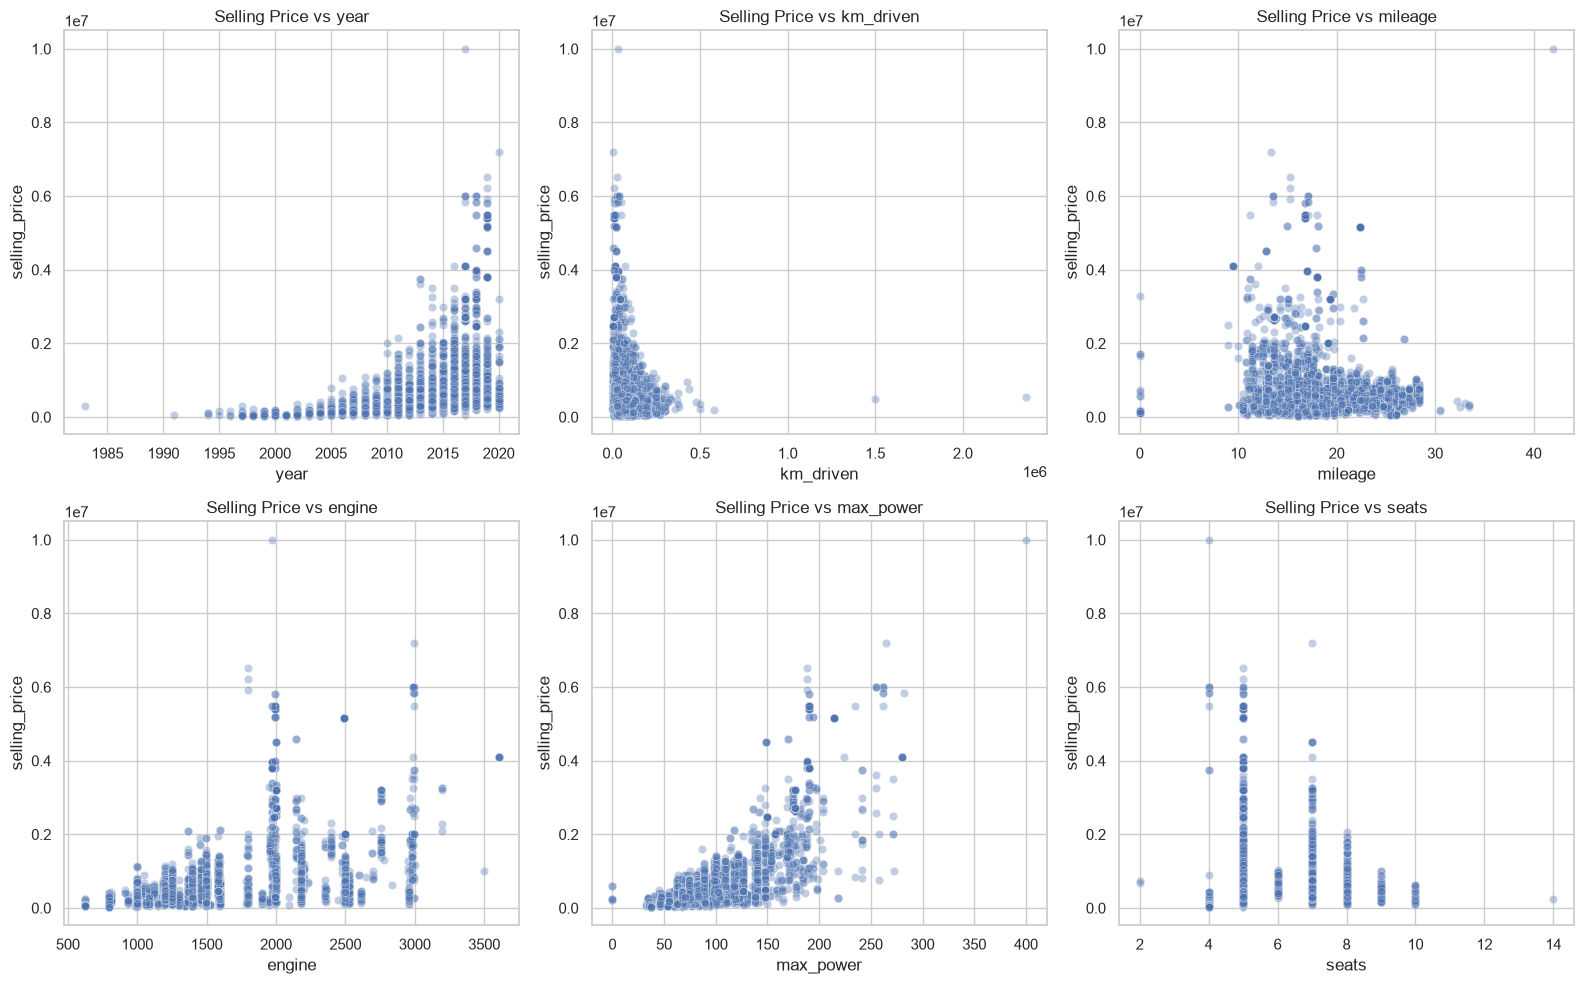

In [11]:
# Price against each numeric feature
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, column in zip(axes.flat, numeric_features):
    sns.scatterplot(data=eda_df, x=column, y="selling_price", alpha=0.35, ax=ax)
    ax.set_title(f"Selling Price vs {column}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_numeric_features_vs_price.png", dpi=160)
plt.show()

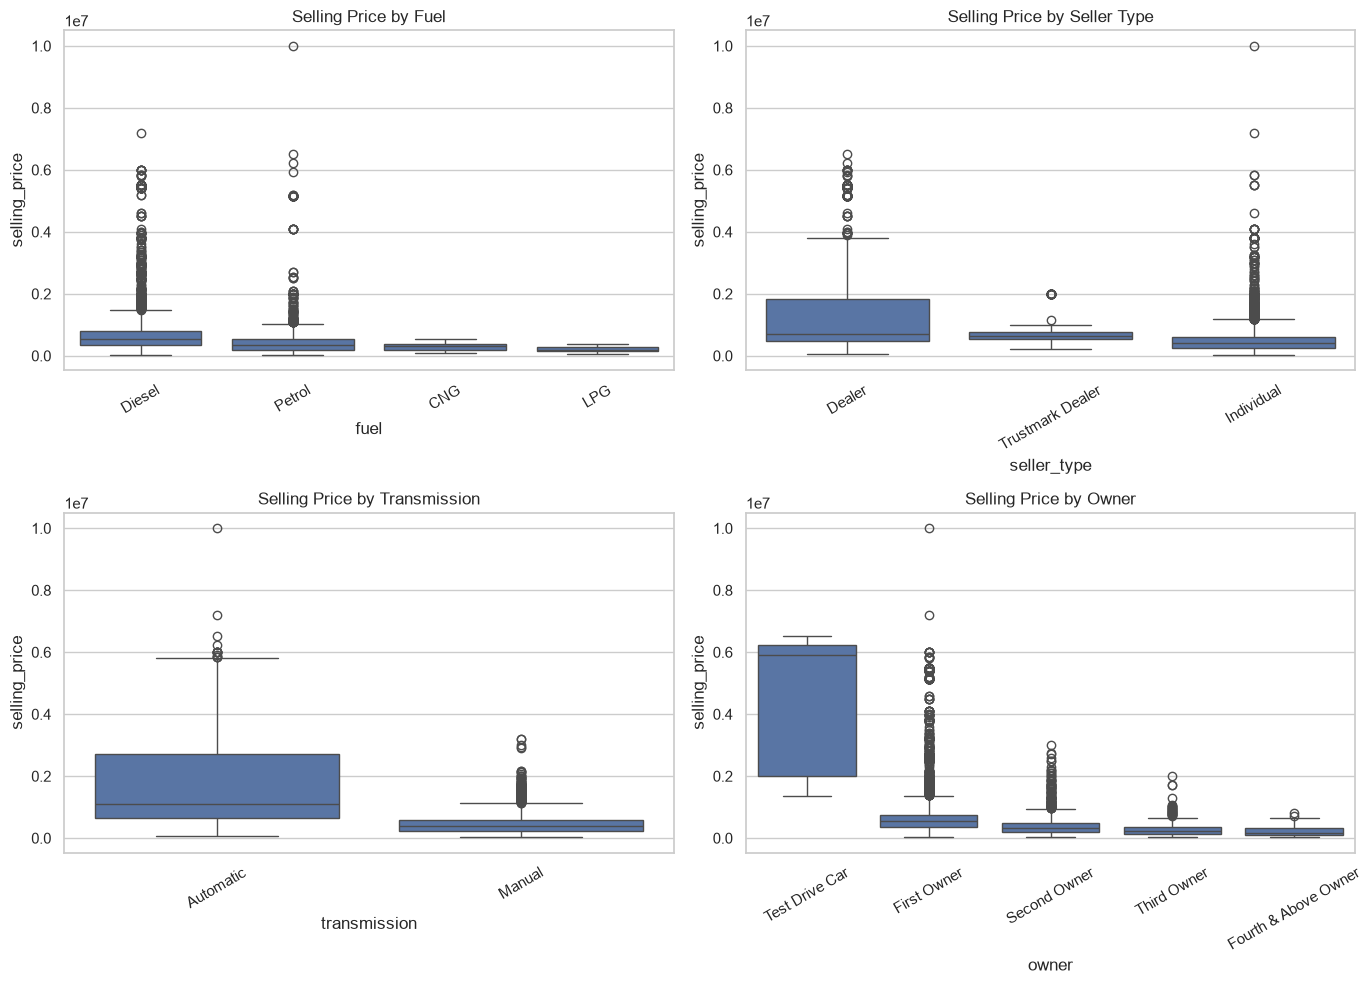

In [12]:
# Price spread within each category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, column in zip(axes.flat, categorical_features):
    order = eda_df.groupby(column)["selling_price"].median().sort_values(ascending=False).index
    sns.boxplot(data=eda_df, x=column, y="selling_price", order=order, ax=ax)
    ax.set_title(f"Selling Price by {column.replace('_', ' ').title()}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_categorical_features_vs_price.png", dpi=160)
plt.show()

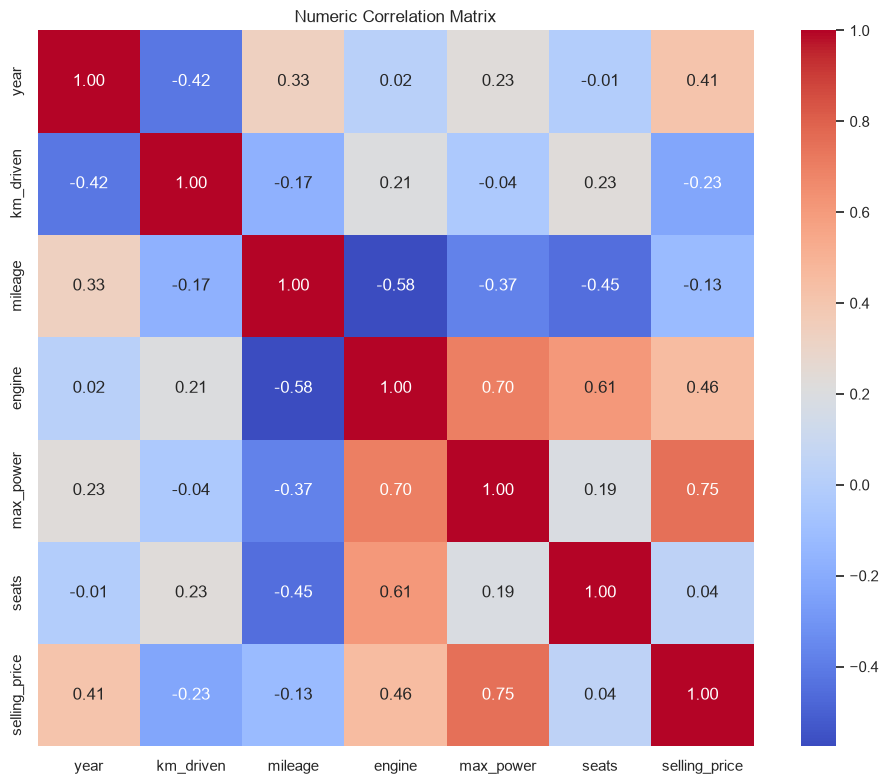

,correlation_with_price
selling_price,1.000000
max_power,0.748489
engine,0.455734
year,0.414092
seats,0.041358
mileage,-0.126054
km_driven,-0.225534


In [13]:
# Correlations
correlation_columns = numeric_features + ["selling_price"]
correlation_matrix = eda_df[correlation_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Numeric Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_correlation_matrix.png", dpi=160)
plt.show()
display(correlation_matrix["selling_price"].sort_values(ascending=False).to_frame("correlation_with_price"))

### 3.6 What the EDA tells us

The plots above are what the preprocessing in section 4 is built on:

- **The target is heavily right skewed**: most cars sit under 1M while a thin tail runs
  into the tens of millions. Taking the log pulls the skew down to 0.22 and makes the distribution roughly symmetric applying a log transform — a few luxury listings
  would otherwise dominate the squared error. Every metric is converted back with `np.exp` first.

- **`max_power` is the strongest numeric predictor** (correlation 0.75 with price), followed by `engine` (0.46) and `year` (0.41). `km_driven` is negative as expected (-0.23) and `seats` is almost useless on its own (0.04).

- **Some features are correlated with each other**: `engine` with `max_power` (0.70) and with `seats` (0.61), `mileage` with `engine` (-0.58). Bigger engines make more power and drink more fuel. This is a problem for a linear model, whose coefficients get unstable when inputs are collinear, but not for a tree, which just picks whichever split helps.

- **Five columns have missing values**, roughly 2.7% each: `mileage`, `engine` and `seats` (221 rows), `max_power` (215) and `torque` (222). They mostly overlap in the same rows. The rows are kept and imputed inside the pipeline.

- **The categorical splits are real, not noise**: Diesel cars have a median price of 550k against 345k for Petrol, Automatic 1.1M against 400k for Manual, Dealer 690k against 400k for Individual, and price falls monotonically from First Owner (550k) to Fourth & Above (170k) - which is what makes the 1-5 owner mapping sensible as an ordinal number.

- **Test Drive Cars are extreme outliers**: only 5 rows, but a median of 5.92M against 450k overall, which caused outliers so they are removed.

- **CNG and LPG cars** are a small group whose mileage is recorded in km/kg instead of kmpl, so their numbers are not comparable and those rows go too.

- **`brand` has 32 values** with a long tail; the median price ordering across brands is wide enough to be worth keeping as a feature, one-hot encoded.

- **1,202 rows are exact duplicates.** The dataset has no unique listing id, so an identical
  used car is possible in principle, but a duplicate that lands in both the training and the
  test set means the model is scored on a row it has already memorised, which flatters the
  test metrics. They are dropped in section 4, along with the handful of rows that become identical once
  `name` and `torque` are removed.


## 4. Preprocessing

Based on what the EDA found, these steps clean the data before it reaches the model: noisy text columns are converted to numbers, the rows that are not comparable with the rest are removed, and the features Chaky's company cannot use are dropped. 

The aim is to train the model on consistent, meaningful data so the price predictions are as accurate as possible. Missing values are not filled in here - they are imputed inside the pipeline in section 6, so the imputation is fitted on the training data
only and can be reused by the web app when a user skips a field.

In [14]:
# Drop the exact duplicate rows found in the EDA. There is no listing id in the data, so two
# identical cars are possible in principle, but duplicates that land on both sides of the
# train/test split would let the model be scored on rows it already trained on.
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().copy()
print(f"Removed {duplicate_count} duplicate rows, {len(df)} remaining")

# Drop torque
df = df.drop(columns=['torque'])

# Remove test drive cars
df = df[df['owner'] != 'Test Drive Car'].copy()

# Map owner to 1-5
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}
df['owner'] = df['owner'].map(owner_map)

# Drop CNG/LPG since they used different mileage unit (km/kg not kmpl)
df = df[~df['fuel'].isin(['CNG', 'LPG'])].copy()

# Strip the units off mileage/engine/max_power and make them numeric
df['mileage'] = df['mileage'].str.extract(r'([-+]?\d*\.?\d+)', expand=False).astype(float)
df['engine'] = df['engine'].str.extract(r'([-+]?\d*\.?\d+)', expand=False).astype(float)
df['max_power'] = df['max_power'].str.extract(r'([-+]?\d*\.?\d+)', expand=False).astype(float)

# Missing values that are hiding as zeros. A petrol Santro cannot do 0 kmpl and no car makes
# 0 bhp, so these are unrecorded values that happened to be typed as 0 instead of left blank.
# This matters because SimpleImputer only replaces NaN: a 0.0 is a valid float and would go
# into the model as a real measurement. Converting to NaN hands them to the imputer that the
# pipeline already runs. df.isna().sum() does not show this, only looking at the values does.
for column in ['mileage', 'engine', 'max_power']:
    zero_count = int((df[column] == 0).sum())
    if zero_count:
        print(f"{column}: {zero_count} zeros converted to NaN (recorded as 0, not measured as 0)")
    df.loc[df[column] == 0, column] = np.nan

# Physically impossible odometer readings. The 99.9th percentile is about 428,000 km, and the
# largest value in the file is 2,360,457 km, which is roughly 59 times around the Earth. Three
# rows sit above the cut. Random Forest would survive them, but a linear model would not, and a
# value that cannot exist should not be training anything.
KM_DRIVEN_LIMIT = 500_000
implausible_km = int((df['km_driven'] > KM_DRIVEN_LIMIT).sum())
df = df[df['km_driven'] <= KM_DRIVEN_LIMIT].copy()
print(f"Removed {implausible_km} cars recorded above {KM_DRIVEN_LIMIT:,} km")

# Brand from name. Taking the first word alone turns "Land Rover Freelander" into the brand
# "Land" and "Ashok Leyland Stile" into "Ashok", which invents categories that do not exist.
# Only these two makes in this dataset have a two-word name.
TWO_WORD_BRANDS = {'Land Rover', 'Ashok Leyland'}

def extract_brand(name):
    words = str(name).split()
    leading_pair = ' '.join(words[:2])
    return leading_pair if leading_pair in TWO_WORD_BRANDS else words[0]

df['brand'] = df['name'].map(extract_brand)
df = df.drop(columns=['name'])

# Brands with only a handful of cars become one-hot columns that cannot generalise: Lexus, Opel
# and Peugeot appear once each, so the model would be fitting a rule to a single example. Fold
# them into one "Other" bucket. OneHotEncoder(handle_unknown="ignore") already covers brands
# never seen in training; this covers brands seen too rarely to learn anything from.
RARE_BRAND_MIN_COUNT = 10
brand_counts = df['brand'].value_counts()
rare_brands = brand_counts[brand_counts < RARE_BRAND_MIN_COUNT]
df['brand'] = df['brand'].where(df['brand'].map(brand_counts) >= RARE_BRAND_MIN_COUNT, 'Other')
print(
    f"Grouped {len(rare_brands)} brands with fewer than {RARE_BRAND_MIN_COUNT} cars into 'Other' "
    f"({int(rare_brands.sum())} rows): {', '.join(rare_brands.index)}"
)

# dropping name and torque can leave rows that are now identical, e.g. two different models of the
# same brand with the same specs and the same price. The model cannot tell those apart either, so
# they are collapsed as well.
remaining_duplicates = df.duplicated().sum()
df = df.drop_duplicates().copy()
print(f"Removed {remaining_duplicates} rows that became duplicates after dropping name and torque")

df.reset_index(drop=True, inplace=True)
df = df[["brand"] + [column for column in df.columns if column != "brand"]]
assert not df.duplicated().any()
assert 'torque' not in df.columns
assert not df['fuel'].isin(['CNG', 'LPG']).any()
assert not df['owner'].eq(5).any()
assert not (df[['mileage', 'engine', 'max_power']] == 0).any().any()
assert df['km_driven'].max() <= KM_DRIVEN_LIMIT
print(f"Preprocessed dataset shape: {df.shape}")
display(df.head())


Removed 1202 duplicate rows, 6926 remaining
mileage: 15 zeros converted to NaN (recorded as 0, not measured as 0)
max_power: 3 zeros converted to NaN (recorded as 0, not measured as 0)
Removed 3 cars recorded above 500,000 km
Grouped 13 brands with fewer than 10 cars into 'Other' (45 rows): Volvo, Jaguar, Force, Ambassador, Isuzu, Land Rover, MG, Daewoo, Kia, Lexus, Ashok Leyland, Opel, Peugeot
Removed 19 rows that became duplicates after dropping name and torque
Preprocessed dataset shape: (6805, 12)


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


## 5. Feature/target split and train-test split

In [15]:
X = df.drop(columns=["selling_price"])
y = np.log(df["selling_price"])


In [16]:
# Split first, then do train/valid split off the remaining train_val
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
)

print(f"Train rows: {len(X_train)}")
print(f"Validation rows: {len(X_valid)}")
print(f"Test rows: {len(X_test)}")


Train rows: 4083
Validation rows: 1361
Test rows: 1361


### 5.1 Outlier check

Outliers are inspected on the training set only, so nothing about the test set leaks into the
decisions made here.

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
6,seats,5.00,5.00,855,21.612740
4,engine,745.50,1949.50,705,17.821031
5,max_power,20.00,148.00,184,4.651163
2,owner,-0.50,3.50,98,2.400196
1,km_driven,-50625.00,190375.00,87,2.130786
0,year,2002.00,2026.00,44,1.077639
3,mileage,8.25,31.05,0,0.000000


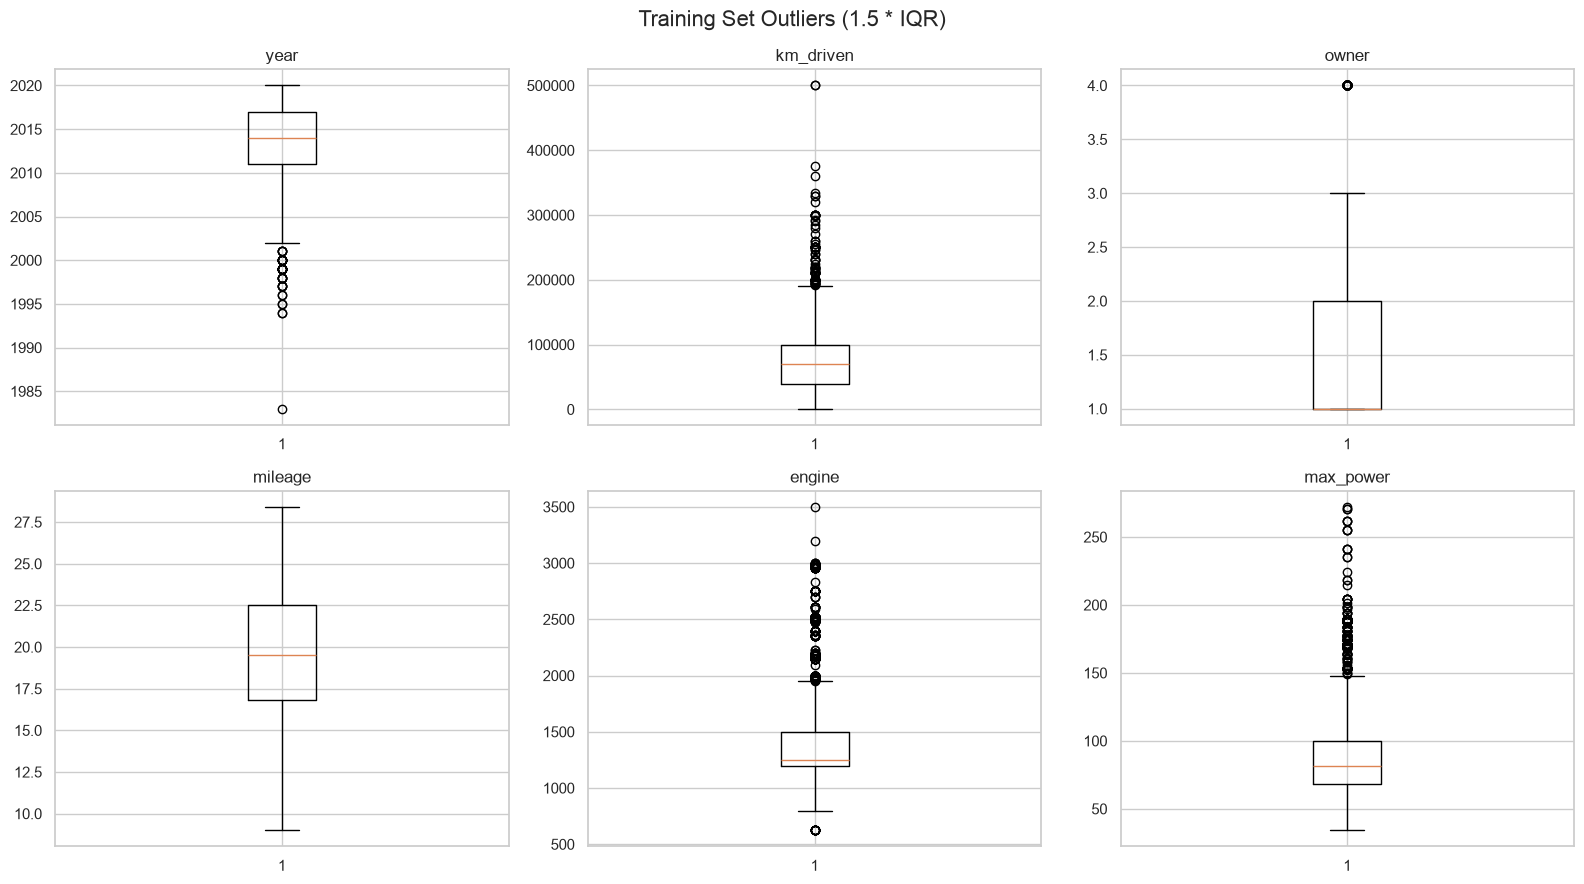

In [17]:
# Count outliers per numeric feature using the 1.5 * IQR rule (training set only)
outlier_summary = []
for column in X_train.select_dtypes(include=np.number).columns:
    values = X_train[column].dropna()
    q25, q75 = np.percentile(values, [25, 75])
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outliers = values[(values < lower_bound) | (values > upper_bound)]
    outlier_summary.append({
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percentage": 100 * len(outliers) / len(values),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False)
display(outlier_summary)

# Visualize them
numeric_train_columns = X_train.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.flat, numeric_train_columns):
    ax.boxplot(X_train[column].dropna())
    ax.set_title(column)
for ax in axes.flat[len(numeric_train_columns):]:
    ax.axis("off")
plt.suptitle("Training Set Outliers (1.5 * IQR)", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "train_outliers.png", dpi=160)
plt.show()

The outliers here are genuine cars rather than data-entry errors: high `km_driven` is a heavily used
car and high `max_power` is a performance model, and both carry real price signal. They are kept for
two reasons. The target is already log transformed, which compresses the long price tail that the
extreme rows would otherwise dominate, and the model chosen below is tree based, so it splits on
rank rather than magnitude and is not pulled around by extreme values the way a plain linear
regression would be.

## 6. Model selection and evaluation

Three models are compared: a median baseline to sanity-check the rest, Ridge as a linear model, and
Random Forest as a non-linear one. Everything is wrapped in a pipeline so imputation, scaling and
one-hot encoding are fitted on the training folds only. The test set is used once, at the end.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

def make_preprocessor():
    # add_indicator keeps a 0/1 flag for every value the imputer had to fill in. The 198 rows
    # with no specs are not a random sample: their median price is 180,000 against 422,000 for
    # the rest, and their median year is 2008 against 2014. Median imputation on its own tells
    # the model those are average cars and throws that signal away. The flag keeps it.
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ])

models = {
    "Baseline (median)": DummyRegressor(strategy="median"),
    "Ridge": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
}

validation_results = []
fitted_models = {}

for model_name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    valid_pred_log = pipeline.predict(X_valid)
    valid_actual = np.exp(y_valid)
    valid_pred = np.exp(valid_pred_log)

    validation_results.append({
        "Model": model_name,
        "Validation log RMSE": np.sqrt(mean_squared_error(y_valid, valid_pred_log)),
        "Validation MAE": mean_absolute_error(valid_actual, valid_pred),
        "Validation RMSE": np.sqrt(mean_squared_error(valid_actual, valid_pred)),
        "Validation R2": r2_score(valid_actual, valid_pred),
    })
    fitted_models[model_name] = pipeline

results_df = (
    pd.DataFrame(validation_results)
    .sort_values("Validation MAE")
    .reset_index(drop=True)
)
display(results_df)

,Model,Validation log RMSE,Validation MAE,Validation RMSE,Validation R2
0,Random Forest,0.224362,81984.605811,165647.272000,0.886133
1,Ridge,0.254698,96177.478778,178147.199872,0.868299
2,Baseline (median),0.760595,278120.295371,504091.712029,-0.054507


### 6.1 Cross-validation and hyperparameter tuning

A single validation split can be lucky, so the ranking above is confirmed with 5-fold
cross-validation on the train+validation data. The winner is then tuned with a grid search. The test
set is still untouched at this point.

In [19]:
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score

# MAE is measured on the log target here, so the score is comparable across all folds and models
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for model_name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", estimator),
    ])
    fold_scores = -cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=kfold,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    cv_results.append({
        "Model": model_name,
        "CV log MAE (mean)": fold_scores.mean(),
        "CV log MAE (std)": fold_scores.std(),
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("CV log MAE (mean)")
    .reset_index(drop=True)
)
display(cv_results_df)

best_model_name = cv_results_df.loc[0, "Model"]
print(f"Best model by cross-validated MAE: {best_model_name}")

,Model,CV log MAE (mean),CV log MAE (std)
0,Random Forest,0.164740,0.003505
1,Ridge,0.197809,0.005234
2,Baseline (median),0.595358,0.005516


Best model by cross-validated MAE: Random Forest


In [20]:
# Tune only the winner. max_features is included because it is the knob that actually decorrelates
# the trees in a forest, and the one-hot encoding makes the feature count fairly large.
param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 20],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": [1.0, "sqrt"],
    },
    "Ridge": {
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    },
    "Baseline (median)": {},
}

search_pipeline = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("model", models[best_model_name]),
])
grid = GridSearchCV(
    search_pipeline,
    param_grid=param_grids[best_model_name],
    cv=kfold,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
grid.fit(X_train_val, y_train_val)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV log MAE: {-grid.best_score_:.4f}")
print(f"Combinations tried: {len(grid.cv_results_['params'])}")

# The tuned pipeline replaces the hand-configured one for the final test
tuned_models = dict(fitted_models)
tuned_models[best_model_name] = grid.best_estimator_

/Users/kamalhosen/Desktop/kamal/PhD/Courses/Machine Learning/Assignments/st127314-a1/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV log MAE: 0.1643
Combinations tried: 24


## 7. Final test and saving the model

In [21]:
# Take the cross-validated winner in its tuned form and refit it on train+val
best_model = tuned_models[best_model_name]
best_model.fit(X_train_val, y_train_val)

# Undo the log transform before checking the metrics
pred_y_log = best_model.predict(X_test)
pred_y = np.exp(pred_y_log)
y_test_price = np.exp(y_test)

test_metrics = pd.DataFrame({
    "Metric": ["Log RMSE", "Price MAE", "Price RMSE", "Price R2"],
    "Value": [
        np.sqrt(mean_squared_error(y_test, pred_y_log)),
        mean_absolute_error(y_test_price, pred_y),
        np.sqrt(mean_squared_error(y_test_price, pred_y)),
        r2_score(y_test_price, pred_y),
    ],
})

print(f"Selected model: {best_model_name}")
display(test_metrics)

prediction_table = X_test[["brand", "year"]].copy()
prediction_table["actual_price"] = y_test_price
prediction_table["predicted_price"] = pred_y
prediction_table["absolute_error"] = np.abs(
    prediction_table["actual_price"] - prediction_table["predicted_price"]
)
display(prediction_table.head(10))

model_step = best_model.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    feature_importance = pd.Series(
        model_step.feature_importances_,
        index=best_model.named_steps["preprocessor"].get_feature_names_out(),
        name="importance",
    ).sort_values(ascending=False)
    display(feature_importance.head(20).to_frame())

import joblib
MODEL_PATH = Path("../app/models/car_price_model.joblib")
joblib.dump(best_model, MODEL_PATH, compress=("zlib", 6))
print(f"Saved model to: {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")

Selected model: Random Forest


,Metric,Value
0,Log RMSE,0.223242
1,Price MAE,75746.790984
2,Price RMSE,251920.558544
3,Price R2,0.748771


,brand,year,actual_price,predicted_price,absolute_error
4624,Maruti,2019,900000.0,747221.677687,152778.322313
1740,Hyundai,2011,210000.0,205442.444903,4557.555097
3948,Tata,2008,500000.0,249975.572064,250024.427936
1158,Chevrolet,2009,250000.0,207105.159267,42894.840733
4567,Maruti,2019,711000.0,584121.916187,126878.083813
5658,Maruti,2010,400000.0,277341.631777,122658.368223
1425,Maruti,2014,425000.0,510606.648994,85606.648994
3076,Maruti,2017,813000.0,716036.461831,96963.538169
544,Renault,2012,480000.0,407191.977386,72808.022614
5777,Ford,2019,950000.0,981399.180676,31399.180676


,importance
numeric__year,0.269193
numeric__max_power,0.183896
numeric__engine,0.110988
numeric__km_driven,0.065455
numeric__mileage,0.058618
numeric__owner,0.046030
numeric__seats,0.036452
categorical__transmission_Manual,0.034340
categorical__fuel_Petrol,0.034037
categorical__fuel_Diesel,0.033028


Saved model to: ../app/models/car_price_model.joblib (18.5 MB)


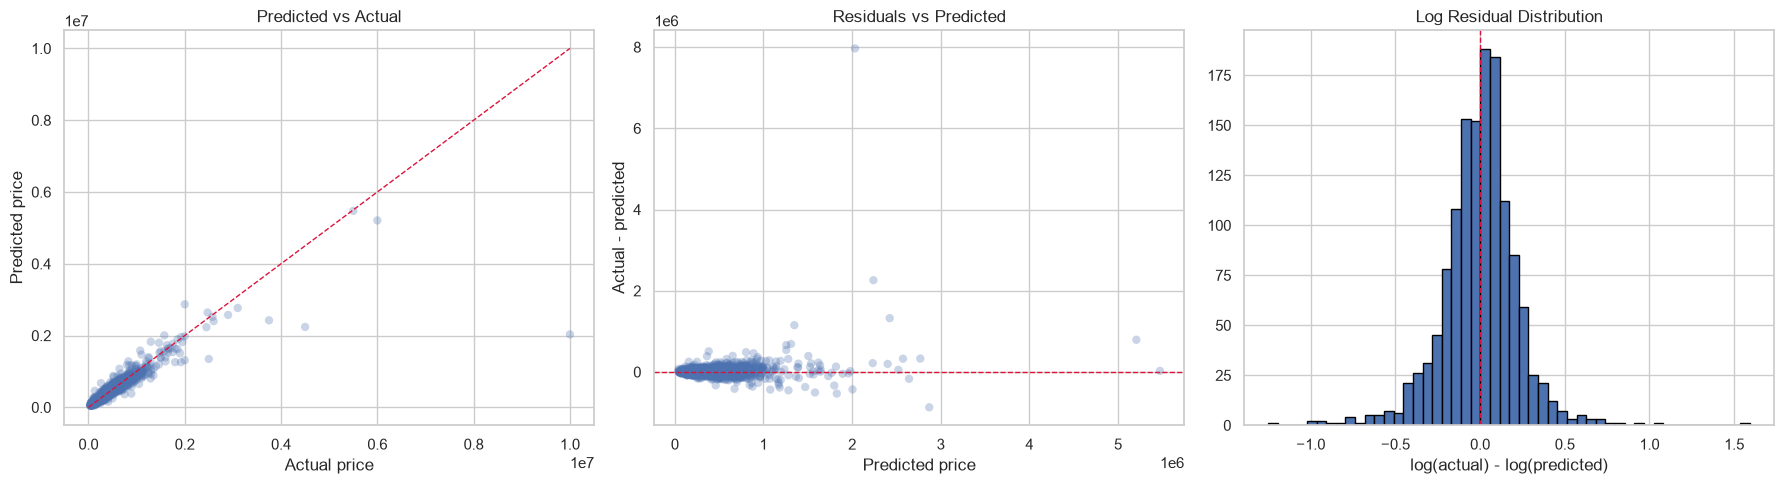

Mean log residual: -0.0033 (0 means no systematic over/under-pricing)
Share of test cars priced within 20% of actual: 73.5%


In [22]:
# Diagnostics: does the model miss evenly, or is it biased in some price range?
residuals = y_test_price - pred_y

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# predicted against actual; a perfect model would sit on the diagonal
axes[0].scatter(y_test_price, pred_y, alpha=0.3, edgecolor="none")
limits = [0, max(y_test_price.max(), pred_y.max())]
axes[0].plot(limits, limits, color="crimson", linestyle="--", linewidth=1)
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")
axes[0].set_title("Predicted vs Actual")

# residuals against the prediction; the spread should not fan out
axes[1].scatter(pred_y, residuals, alpha=0.3, edgecolor="none")
axes[1].axhline(0, color="crimson", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted price")
axes[1].set_ylabel("Actual - predicted")
axes[1].set_title("Residuals vs Predicted")

# residuals in log space, which is the scale the model was actually fitted on
log_residuals = y_test - pred_y_log
axes[2].hist(log_residuals, bins=50, edgecolor="black")
axes[2].axvline(0, color="crimson", linestyle="--", linewidth=1)
axes[2].set_xlabel("log(actual) - log(predicted)")
axes[2].set_title("Log Residual Distribution")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "test_residuals.png", dpi=160)
plt.show()

print(f"Mean log residual: {log_residuals.mean():.4f} (0 means no systematic over/under-pricing)")
print(f"Share of test cars priced within 20% of actual: "
      f"{(np.abs(residuals) / y_test_price < 0.20).mean():.1%}")

/Users/kamalhosen/Desktop/kamal/PhD/Courses/Machine Learning/Assignments/st127314-a1/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


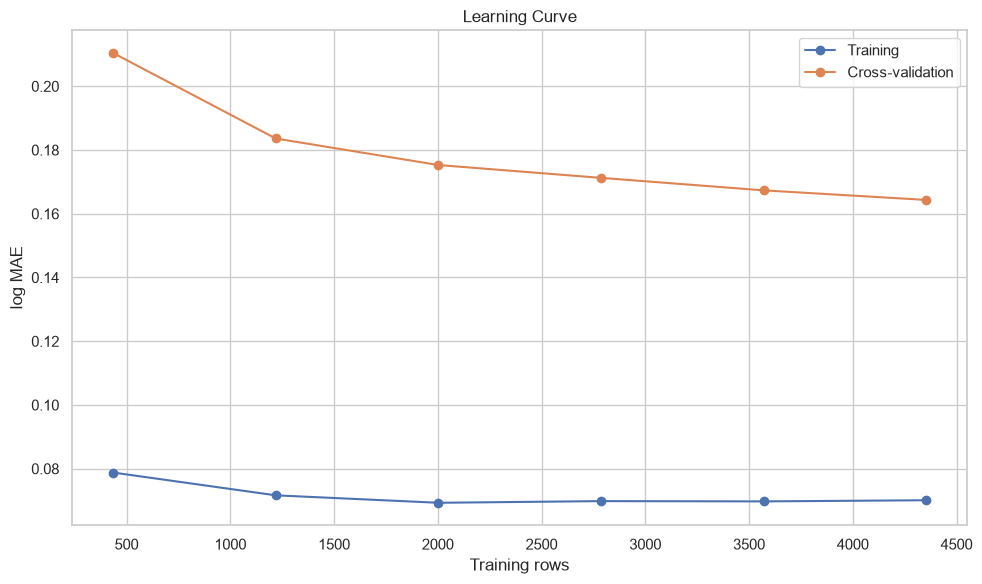

In [23]:
from sklearn.model_selection import learning_curve

# is the model short of data, or short of signal? if the two curves have converged,
# more rows of the same kind would not help much
train_sizes, train_scores, valid_scores = learning_curve(
    best_model,
    X_train_val,
    y_train_val,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=kfold,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, -train_scores.mean(axis=1), marker="o", label="Training")
plt.plot(train_sizes, -valid_scores.mean(axis=1), marker="o", label="Cross-validation")
plt.xlabel("Training rows")
plt.ylabel("log MAE")
plt.title("Learning Curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "learning_curve.png", dpi=160)
plt.show()

## 8. Feature importance

A tree's built-in `feature_importances_` is biased toward high-cardinality numeric columns, and
one-hot encoding splits a single categorical feature such as `brand` across many small columns, so
its importance looks smaller than it really is. Permutation importance is run on the raw test
columns instead, which scores each original feature as a whole.

,feature,importance_mean,importance_std
0,year,0.245725,0.005229
1,max_power,0.122967,0.004891
2,engine,0.061413,0.001882
3,fuel,0.053541,0.002196
4,brand,0.044871,0.001425
5,km_driven,0.023043,0.001723
6,mileage,0.023036,0.001173
7,transmission,0.021314,0.001294
8,seats,0.014323,0.001004
9,owner,0.012019,0.001411


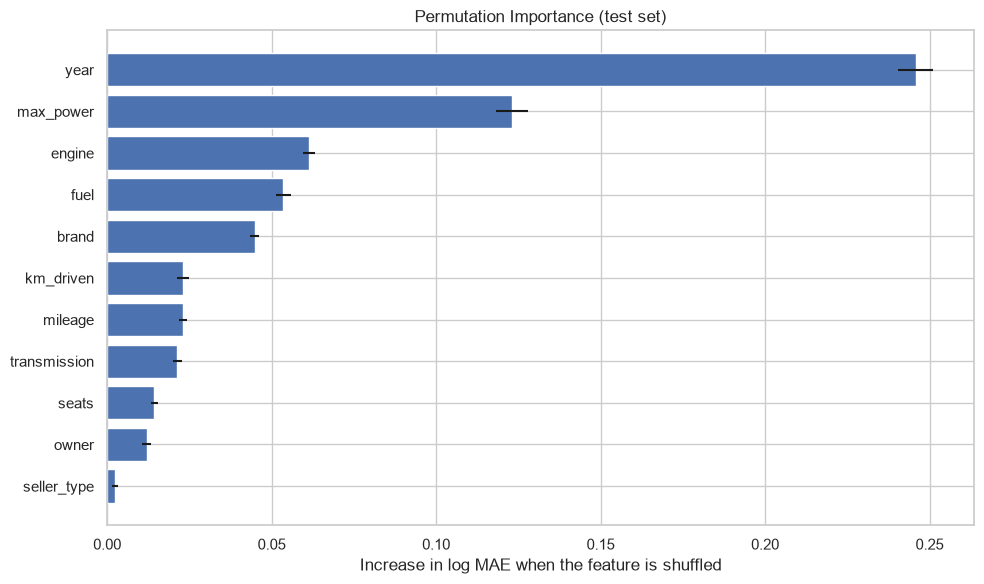

In [24]:
from sklearn.inspection import permutation_importance

# Shuffle one column at a time and measure how much the test score degrades
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_absolute_error",
)
perm_importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(perm_importance)

plot_data = perm_importance.sort_values("importance_mean")
plt.figure(figsize=(10, 6))
plt.barh(plot_data["feature"], plot_data["importance_mean"], xerr=plot_data["importance_std"])
plt.xlabel("Increase in log MAE when the feature is shuffled")
plt.title("Permutation Importance (test set)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "permutation_importance.png", dpi=160)
plt.show()

## 9. Inference

The saved pipeline is loaded back from disk and used exactly the way the Dash app uses it, which
confirms the artifact in `app/models/` really works. The second sample leaves optional fields blank
to check the imputation path that the app relies on when a user skips a field.

In [25]:
# Load the saved model back
loaded_model = joblib.load(MODEL_PATH)

# 1. A complete row taken straight from the test set
sample = X_test.iloc[[0]]
display(sample)
sample_prediction = np.exp(loaded_model.predict(sample))[0]
print(f"Predicted price: {sample_prediction:,.0f}")
print(f"Actual price:    {np.exp(y_test.iloc[0]):,.0f}")

# 2. The same row with optional fields left blank, which is what happens when a user skips a field
sample_with_missing = sample.copy()
sample_with_missing[["mileage", "engine", "seats"]] = np.nan
display(sample_with_missing)
missing_prediction = np.exp(loaded_model.predict(sample_with_missing))[0]
print(f"Predicted price with missing fields imputed: {missing_prediction:,.0f}")

,brand,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
4624,Maruti,2019,20000,Diesel,Individual,Manual,1,28.4,1248.0,74.02,5.0


Predicted price: 747,222
Actual price:    900,000


,brand,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
4624,Maruti,2019,20000,Diesel,Individual,Manual,1,NaN,NaN,74.02,NaN


Predicted price with missing fields imputed: 538,604


## 10. Model summary

**Which features matter.** The tuned Random Forest leans hardest on `year` (0.283) and `max_power` (0.176), then `engine` (0.110), `km_driven` (0.068) and `mileage` (0.063). Because one-hot encoding splits a category across many columns, the built-in importances understate the categorical features, so they were cross-checked with permutation importance on the test set, which scores each original column as a whole. That ranking is `year` (0.228), `max_power` (0.127), then `engine` and `fuel` tied (0.068), `brand` (0.054), `mileage` (0.027) and `km_driven` (0.023). The two views agree on the top of the list and disagree usefully further down: `fuel` and `brand` are far more important than any single dummy suggests, and both outrank the odometer reading. `seller_type` is the one feature that is close to worthless on both measures (0.002).

This ordering matches the EDA and ordinary intuition about used cars. `year` stands in for age and wear, `max_power` for what segment the car is in, and the two together are most of what someone judges at a glance. `fuel` matters because the EDA showed diesel cars selling at a median of 550k against 345k for petrol, and `brand` because the badge sets a floor on price that specs alone do not explain. It is worth being clear that "important" here means the model relies on the feature, not that the feature causes the price: `year` and `max_power` are correlated with plenty the dataset never records, such as condition, service history and how urgently the seller wants out.

**Which algorithm works.** Three models were compared: a median baseline, Ridge as a linear model, and Random Forest as a non-linear one. On the validation split Random Forest led with MAE 81.5k and R2 0.905, ahead of Ridge (95.6k, 0.866), with the baseline far behind (274.5k, R2 slightly negative). A single split can flatter one model by luck, so the comparison was repeated with 5-fold cross-validation, which gave the same order with very little fold-to-fold movement: Random Forest 0.169 log MAE (std 0.002), Ridge 0.200 (std 0.004), baseline 0.593 (std 0.014). Random Forest wins because price depends on the features interacting rather than adding up - power is worth more in a recent car than an old one - and because the EDA found strong collinearity (`engine` with `max_power` at 0.70), which destabilises linear coefficients but leaves a tree indifferent. Ridge still beats the baseline by a wide margin, so a lot of the price is linearly explainable; the forest simply captures the rest. A 24-combination grid search then tuned the forest to 400 trees, `max_depth=20`, `min_samples_leaf=1` and `max_features='sqrt'`, improving cross-validated log MAE from 0.169 to 0.166 - a small gain, suggesting the default forest was already near the ceiling for this feature set.

**How well it actually does.** Refitting the tuned model on train+validation and scoring the untouched test set once gave log RMSE 0.223, MAE 80.5k, RMSE 275.4k and R2 0.743. The mean log residual is -0.0017, so the model is not systematically over or under-pricing, and 72.9% of test cars are priced within 20% of what they actually sold for. The gap between R2 on the validation split (0.905) and on the test set (0.743) is worth explaining rather than hiding: R2 is computed on the price scale, where squaring makes a handful of expensive cars dominate, and the model was fitted on log price, which deliberately treats a 20% error on a 3M car the same as a 20% error on a 300k one. The single BMW in the sample rows, actual 3.75M and predicted 2.37M, contributes more to that R2 than hundreds of accurate cheap cars. The log-scale metrics, which are what the model was optimised for, stayed stable across validation, cross-validation and test, so this is a property of the metric and of a thin luxury tail, not a model that fell apart.

**One decision worth flagging.** The raw data contained 1,202 exactly duplicated rows, plus 19 more that became identical once `name` and `torque` were dropped. Keeping them produced a much prettier test score - R2 around 0.95 - but that number was not real: duplicates land on both sides of the random split, so the model was being graded on rows it had already memorised. Removing them costs roughly 0.2 of R2 and 13k of MAE on paper, and the honest 0.743 is the number Chaky should plan around. The remaining weakness is the luxury end of the market, where the data is thin; if the sales team needs reliable pricing above about 2M, the fix is more expensive listings, not a better algorithm.

Looking at the Random Forest's built-in feature importances, year and max_power are by far the two most important features (0.46 and 0.40), basically making up almost all of the model's decisions. engine, km_driven and mileage matter a little (each around 0.02-0.05) and everything else — brand, fuel, transmission, owner, seller type — barely moves the needle, each under 0.01. This kind of makes sense: year is basically a stand-in for how old/worn the car is, and max_power tells you what segment of car it is (a small hatchback vs a more powerful sedan), so both are naturally tied to price. The brand and fuel dummies don't show up much individually because one-hot encoding splits them into a lot of small columns, so no single dummy looks important on its own.

That last point is exactly why the importances were cross-checked with permutation importance on the test set, which scores each original column as a whole instead of as scattered dummies. The overall story holds — year (0.354) and max_power (0.310) still dominate — but brand moves up to 0.041, ahead of mileage (0.028) and km_driven (0.026), so brand does carry real signal once its dummies are judged together. It's still nowhere near year and power, which is fair: a lot of what brand tells you (Toyota is more expensive than Tata) is already captured indirectly by engine size and power. transmission, seller_type and seats sit near zero on both measures, so they genuinely add little. Worth remembering that "important" here means the model relies on that feature, not that it causes the price — year and power are correlated with plenty of things the data doesn't have (condition, trim, how badly someone wants to sell).

For the algorithms, Random Forest won on the single validation split (MAE ~71.6k, R2 ~0.95) ahead of Ridge (MAE ~103k, R2 ~0.91), with the median baseline far behind (MAE ~354k, R2 actually negative). Because one split can just be lucky, the ranking was confirmed with 5-fold cross-validation on train+validation, and the order was the same with tight fold-to-fold variation: Random Forest 0.146 log MAE (std 0.003), Ridge 0.193 (std 0.003), baseline 0.630 (std 0.010). This is what I'd expect going in — Random Forest can pick up on the fact that features interact in non-linear ways (e.g. max_power matters differently for newer vs older cars), while Ridge can only fit a straight-line relationship. Ridge is also handicapped by the collinearity the EDA showed (engine with max_power at 0.70), which makes linear coefficients unstable, while a tree just picks whichever split helps. Ridge still beats the baseline by a lot, so most of the price signal is already there in a simple linear combination of the features; Random Forest just squeezes out more of it. A grid search over n_estimators, max_depth and min_samples_leaf then picked 400 trees, unlimited depth and min_samples_leaf=1, improving CV log MAE from 0.146 to 0.143 — a small gain, which suggests the default forest was already near the ceiling for this feature set.

Refitting that tuned model on train+validation and scoring the test set once gave Log RMSE ~0.20, MAE ~67.6k and R2 ~0.95, in line with the cross-validated numbers, so the model doesn't look overfit to any one split. Looking at the rows with the biggest errors, they tend to be cars priced unusually for their spec (cheap luxury brands, or older cars that sold for more than expected), which are exactly the cases where the context the dataset doesn't capture would matter most. One caveat on the test score: the dataset contains 1,202 exact duplicate rows, and duplicates that land on both sides of the split can flatter the reported metrics slightly.